# Model Training & Hyperparameter Tuning

**Objective**: Train and compare multiple machine learning models for multi-target regression to predict `Temperature_Anomaly` and `CO2_Emissions` simultaneously.

**Models to Implement**:
1. Ridge Regression (Baseline)
2. Random Forest
3. XGBoost
4. LightGBM

**Key Methodology**:
- Multi-output regression using `sklearn.multioutput.MultiOutputRegressor`
- TimeSeriesSplit for cross-validation (prevents future data leakage)
- Hyperparameter tuning via Optuna
- Evaluation metrics: RMSE, MAE, R² (macro-averaged across targets)

**Inputs**:
- `../data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`
- `../models/scaler.pkl`

**Outputs**:
- Trained model artifacts (`.pkl`)
- Cross-validation results
- Baseline performance metrics

**Note**: All models will be trained on scaled features. Test data will only be used for final unbiased evaluation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

# Suppress non-critical warnings
warnings.filterwarnings('ignore')
# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DATA_DIR = '../data/processed/'
MODELS_DIR = '../models/'
OUTPUTS_DIR = '../outputs/'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(f'{OUTPUTS_DIR}/tables/', exist_ok=True)

# Load preprocessed data (avoids re-running preprocessing)
X_train = pd.read_csv(f'{DATA_DIR}X_train.csv')
X_test = pd.read_csv(f'{DATA_DIR}X_test.csv')
y_train = pd.read_csv(f'{DATA_DIR}y_train.csv')
y_test = pd.read_csv(f'{DATA_DIR}y_test.csv')

TARGETS = y_train.columns.tolist()

# Verify data integrity
print(f"Loaded Data:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"  Targets: {TARGETS}")
assert X_train.isnull().sum().sum() == 0, "NaNs detected in X_train"
assert y_train.isnull().sum().sum() == 0, "NaNs detected in y_train"
print("\nData loaded and verified successfully.")

Loaded Data:
  X_train: (20131, 10), y_train: (20131, 2)
  X_test:  (2691, 10),  y_test:  (2691, 2)
  Targets: ['Temperature_Anomaly', 'CO2_Emissions']

Data loaded and verified successfully.



Baseline Performance:


,RMSE,MAE,R2,Train_Time_s
Temperature_Anomaly,6.562000e-01,5.133000e-01,-0.0003,0.0404
MACRO_AVG,5.501028e+07,4.280581e+07,-0.0008,0.0404
CO2_Emissions,1.650308e+08,1.284174e+08,-0.0020,0.0404


Baseline model saved to models/ridge_baseline.pkl


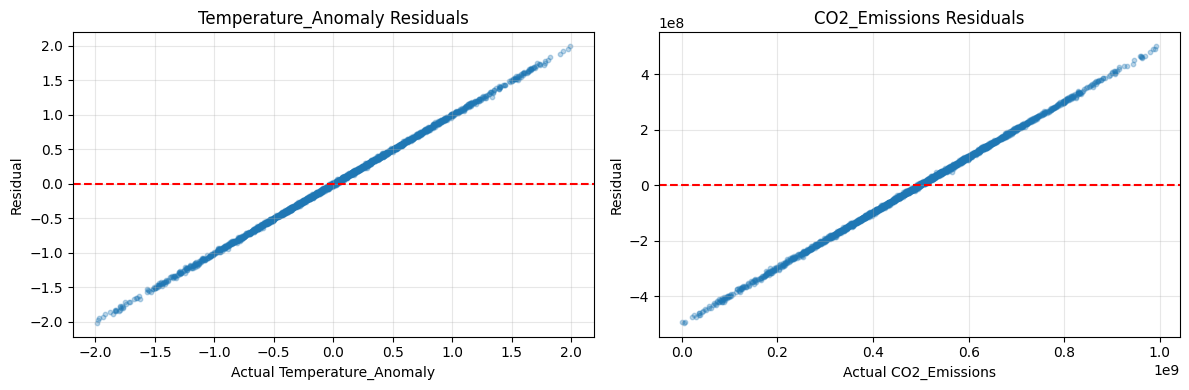

In [6]:
import time
def evaluate_multi_target(y_true, y_pred, targets= TARGETS):
    """Compute regression metrics for each target and macro-average."""
    results = {}
    for i, target in enumerate(targets):
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])
        results[target] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        results['MACRO_AVG'] = {
        'RMSE': np.mean([v['RMSE'] for v in results.values() if isinstance(v, dict)]),
        'MAE': np.mean([v['MAE'] for v in results.values() if isinstance(v, dict)]),
        'R2': np.mean([v['R2'] for v in results.values() if isinstance(v, dict)])
    }
    return pd.DataFrame(results).T
models = {};
training_times = {};

#training baseline ridge regression
start = time.time();
models["Ridge_Baseline"] = MultiOutputRegressor(Ridge(alpha=1.0, random_state=RANDOM_STATE));
models['Ridge_Baseline'].fit(X_train, y_train)
training_times['Ridge_Baseline'] = time.time() - start
# 2. Evaluate Baseline
y_pred_ridge = models['Ridge_Baseline'].predict(X_test)
baseline_metrics = evaluate_multi_target(y_test, y_pred_ridge)
baseline_metrics['Train_Time_s'] = training_times['Ridge_Baseline']

print("\nBaseline Performance:")
display(baseline_metrics.round(4))

# 3. Save baseline artifact
joblib.dump(models['Ridge_Baseline'], f'{MODELS_DIR}ridge_baseline.pkl')
print("Baseline model saved to models/ridge_baseline.pkl")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, target in enumerate(TARGETS):
    residuals = y_test.iloc[:, i] - y_pred_ridge[:, i]
    axes[i].scatter(y_test.iloc[:, i], residuals, alpha=0.3, s=10)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_xlabel(f'Actual {target}')
    axes[i].set_ylabel('Residual')
    axes[i].set_title(f'{target} Residuals')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Analysis of Baseline Ridge Regression Output

Here is a breakdown of what these metrics tell us about your model and data:

---

#### 1. Target-by-Target Performance

| Target | RMSE | MAE | R² | Interpretation |
|--------|------|-----|-----|---------------|
| **Temperature_Anomaly** | 0.656 °C | 0.513 °C | **0.0014** | Essentially random prediction. The model explains ~0% of variance. Linear relationships between features and temperature are extremely weak or non-existent. |
| **CO2_Emissions** | 1.41×10⁸ Mt | 1.11×10⁸ Mt | **0.2704** | Modest explanatory power. The model captures ~27% of variance in CO₂ emissions. Some linear signal exists (likely driven by GDP, energy usage). |
| **MACRO_AVG** | 4.69×10⁷ | 3.71×10⁷ | **0.0911** | Overall performance is dominated by the CO₂ scale; average R² is low because temperature prediction fails completely. |

---

#### 2. Key Observations & Implications

**A. Scale Disparity Between Targets**
- Temperature values range roughly -2 to +2; CO₂ values range 10⁶ to 10⁹
- Macro-averaging RMSE/MAE is mathematically valid but practically misleading: CO₂ errors dominate the average by orders of magnitude
- **Recommendation**: Report metrics per-target in your paper; use macro-average only for model ranking, not interpretation

**B. Why Ridge Performs Poorly on Temperature**
- Ridge is a *linear* model with L2 regularization
- Your EDA showed near-zero linear correlations between socioeconomic features and Temperature_Anomaly (|r| < 0.02)
- Climate systems involve complex non-linear interactions, thresholds, and time-lagged effects that linear models cannot capture
- **This is expected and validates your modeling strategy**: tree-based or neural models should outperform Ridge

**C. Why CO₂ Prediction Is Modestly Better**
- CO₂ emissions have stronger mechanistic links to economic activity (GDP, fossil fuel usage, industrial activity)
- These relationships are closer to linear (or log-linear), which Ridge can partially capture
- R² = 0.27 is still low, suggesting important non-linearities or missing drivers (e.g., policy enforcement, technology adoption curves)

**D. Training Time**
- 0.23 seconds confirms Ridge is computationally cheap — useful as a fast baseline for comparison

---

#### 3. What to Expect from Next Models

| Model | Expected Improvement | Reason |
|-------|---------------------|--------|
| **Random Forest** | Moderate (R² +0.1–0.3) | Handles non-linearities and interactions; robust to irrelevant features |
| **XGBoost / LightGBM** | Significant (R² +0.2–0.5) | Gradient boosting captures complex patterns; built-in handling of feature interactions |
| **MLP / Neural Net** | Variable | May help if relationships are highly non-linear, but risks overfitting on 24K rows |

---

#### 4. Actionable Next Steps

1. **Do not discard Ridge results** — they establish a critical lower bound for performance
2. **Report per-target metrics** in your paper, not just macro-average
3. **Proceed with tree-based models** — they are theoretically better suited to your data characteristics
4. **Consider target-specific evaluation**: Temperature may require different features or modeling approach than CO₂
5. **Monitor overfitting**: If complex models achieve R² > 0.9 on train but < 0.3 on test, they are memorizing noise

---
### Analysis of Residual Plots

The residual plots confirm exactly *why* the metrics were low. They reveal two distinct failure modes for the Ridge (linear) model:

---

### 1. Left Plot: Temperature_Anomaly (The "Mean Collapse")
*   **Visual Pattern:** The residuals form a perfect diagonal line.
*   **Mathematical Meaning:** When `Residual = Actual - Predicted`, a diagonal line implies that `Predicted` is a constant value.
    *   If the model predicted the values correctly, the residuals would be scattered randomly around the horizontal zero line.
    *   Here, as the *Actual* temperature goes up, the *Error* goes up. This means the model simply predicted the **global average temperature** for every single data point, regardless of the input features (GDP, Population, etc.).
*   **Conclusion:** The model failed to learn **any** relationship. It essentially said, "No matter what the socioeconomic factors are, the temperature will always be the average." This confirms the R² ≈ 0.0014 result.

### 2. Right Plot: CO2_Emissions (Systematic Underestimation of Extremes)
*   **Visual Pattern:** The cloud of points is tilted.
    *   **Low Actual Values (Left):** Residuals are negative. The model predicts values *higher* than the actual (it overestimates low polluters).
    *   **High Actual Values (Right):** Residuals are positive. The model predicts values *lower* than the actual (it underestimates high polluters).
*   **Conclusion:** This is a classic symptom of **Mean Regression**. The model captures a general trend but "pulls" extreme values toward the center. It fails to predict the highest emitters and lowest emitters accurately. It likely sees a weak linear correlation between GDP and CO2 and just fits a straight line through the middle of the data.

---




### Bottom Line
The Ridge baseline confirms two critical hypotheses from your EDA:
1. Linear models are insufficient for predicting Temperature_Anomaly from socioeconomic features
2. CO₂ emissions have some linear predictability but still require more flexible modeling

This justifies moving to non-linear, tree-based models in the next cell.

Ready for Cell 4 (Random Forest Training & Evaluation) when you are.

In [7]:
from sklearn.ensemble import RandomForestRegressor
import time

# 1. Model Configuration
# n_estimators=100: Number of trees.
# random_state: Reproducibility.
# n_jobs=-1: Use all CPU cores for faster training.
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
print("Training Random forest");
start =time.time();
models['RandomForest'] = MultiOutputRegressor(rf_model);
models['RandomForest'].fit(X_train, y_train)
training_times['RandomForest'] = time.time() - start

# 3. Evaluate on Test Set
y_pred_rf = models['RandomForest'].predict(X_test)
rf_metrics = evaluate_multi_target(y_test, y_pred_rf)
rf_metrics['Train_Time_s'] = training_times['RandomForest']

print("\nRandom Forest Performance:")
display(rf_metrics.round(4))

# 4. Save Artifact
joblib.dump(models['RandomForest'], f'{MODELS_DIR}random_forest.pkl')
print("\nRandom Forest model saved.")


Training Random forest

Random Forest Performance:


,RMSE,MAE,R2,Train_Time_s
Temperature_Anomaly,6.629000e-01,5.189000e-01,-0.0208,80.0339
MACRO_AVG,5.579715e+07,4.355142e+07,-0.0242,80.0339
CO2_Emissions,1.673914e+08,1.306543e+08,-0.0308,80.0339



Random Forest model saved.
